# 可视化

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import networkx as nx
from matplotlib.colors import Normalize
import warnings
import os
warnings.filterwarnings("ignore")

# 设置中文字体
# 设置中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
original_data_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/dataset/spatial_graph"
correlation_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/analysis/graph/1_correlation"
edge_feature_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/analysis/graph/3_static_graph"

In [3]:
# 1. 加载风机位置数据
location_file = f"{original_data_path}/sdwpf_baidukddcup2022_turb_location.CSV"
location_data = pd.read_csv(location_file)
print(f"✅ 成功加载风机位置数据: {len(location_data)} 台风机")

✅ 成功加载风机位置数据: 134 台风机


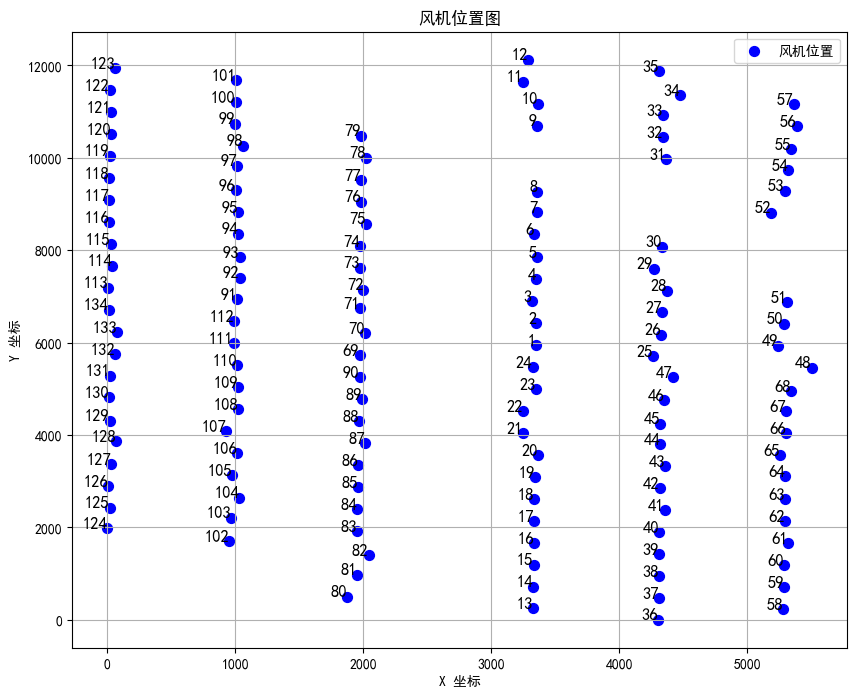

In [6]:
# 画出风机位置图
'''
格式为：TurbID,x,y
1,3349.8515,5939.23193
2,3351.0017,6416.64673
3,3314.7797,6892.18395
4,3352.094,7366.14203
5,3355.342,7841.20175
6,3329.4284,8340.79769
7,3360.5473,8816.23834
8,3360.2992,9265.21442
9,3359.9419,10696.54549
'''

plt.figure(figsize=(10, 8))
plt.scatter(location_data['x'], location_data['y'], c='blue', s=50, label='风机位置')
for i, row in location_data.iterrows():
    plt.text(row['x'], row['y'], str(int(row['TurbID'])), fontsize=12, ha='right')
plt.title('风机位置图')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.legend()
plt.grid(True)
plt.savefig(f"风机位置图.svg", dpi=300)
plt.show()

In [ ]:


# 2. 加载边连接信息
edge_index_file = f"{edge_feature_path}/edge_feature_knn_edge_index.npy"
self.edge_index = np.load(edge_index_file)
print(f"✅ 成功加载边连接信息: {self.edge_index.shape[1]} 条边")

✅ 成功加载风机位置数据: 134 台风机


🚀 启动风电场图网络可视化分析...
📁 将创建单独的图表文件并保存
✅ 成功加载风机位置数据: 134 台风机
✅ 成功加载边连接信息: 760 条边
✅ 成功加载边特征信息: (760, 21)
✅ 成功加载特征名称: 21 个特征
🎨 开始创建各个独立图表...


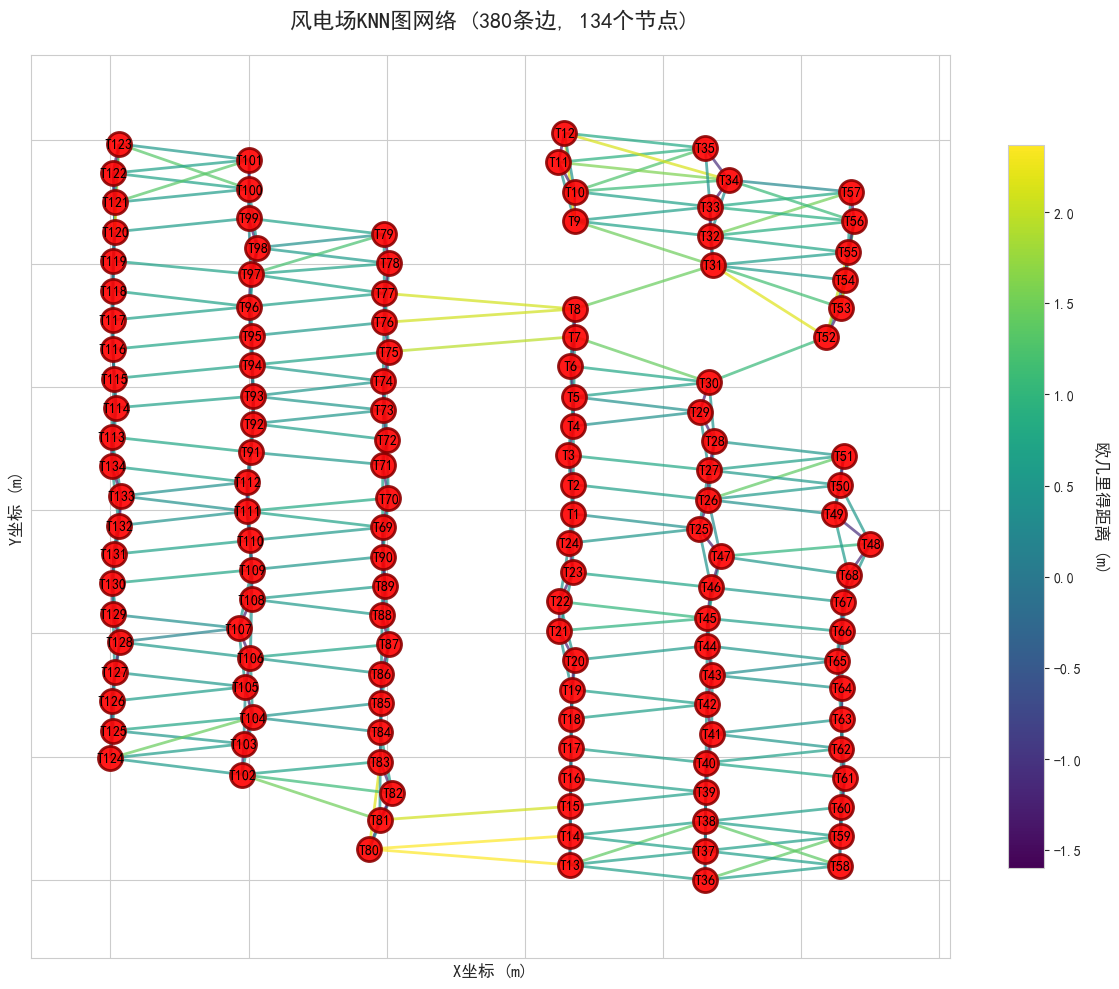

✅ 保存: 01_main_graph_network.png


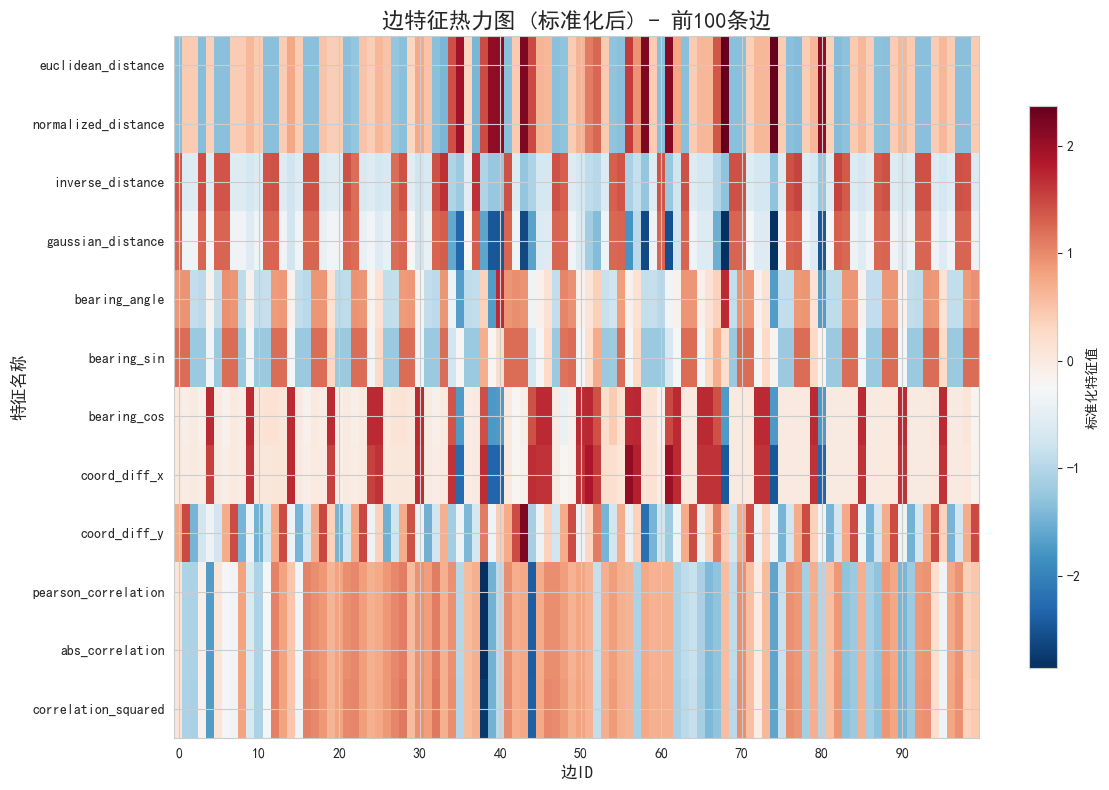

✅ 保存: 02_edge_feature_heatmap.png


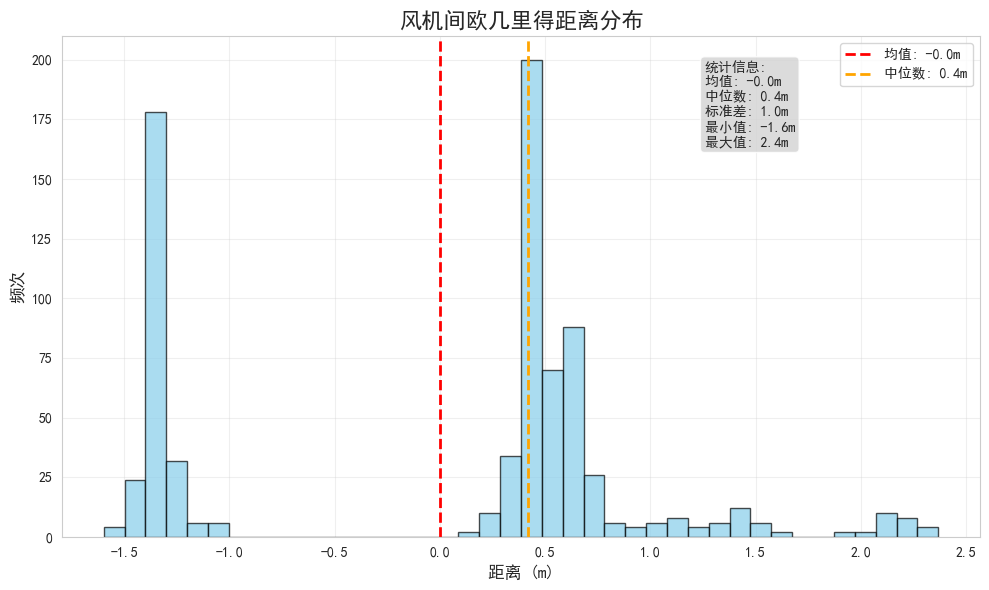

✅ 保存: 03_distance_distribution.png


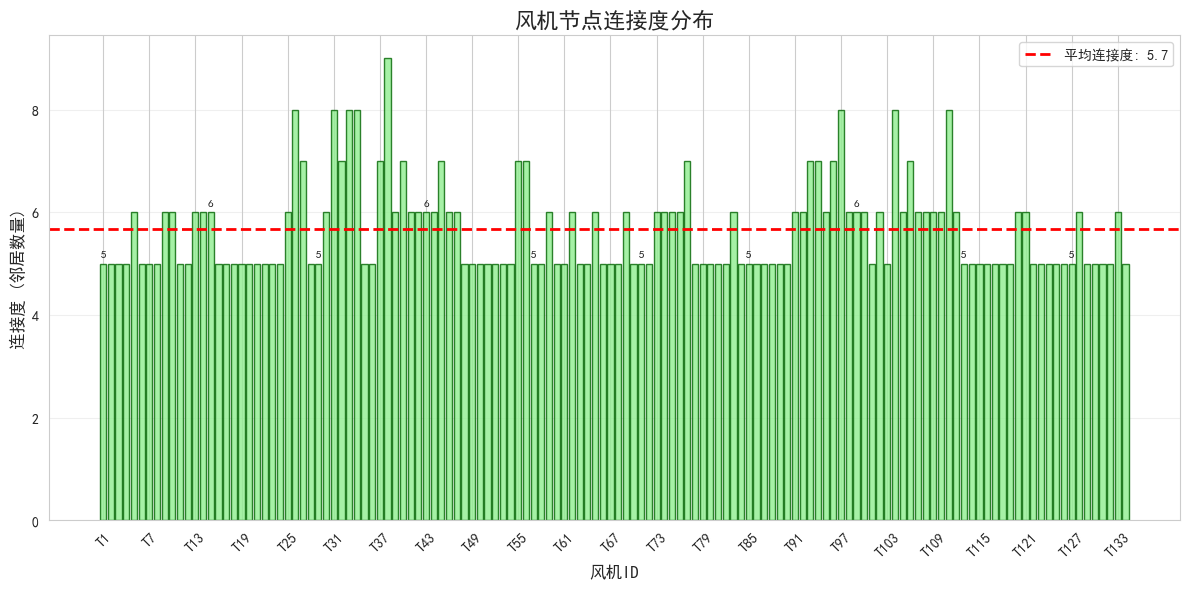

✅ 保存: 04_degree_distribution.png


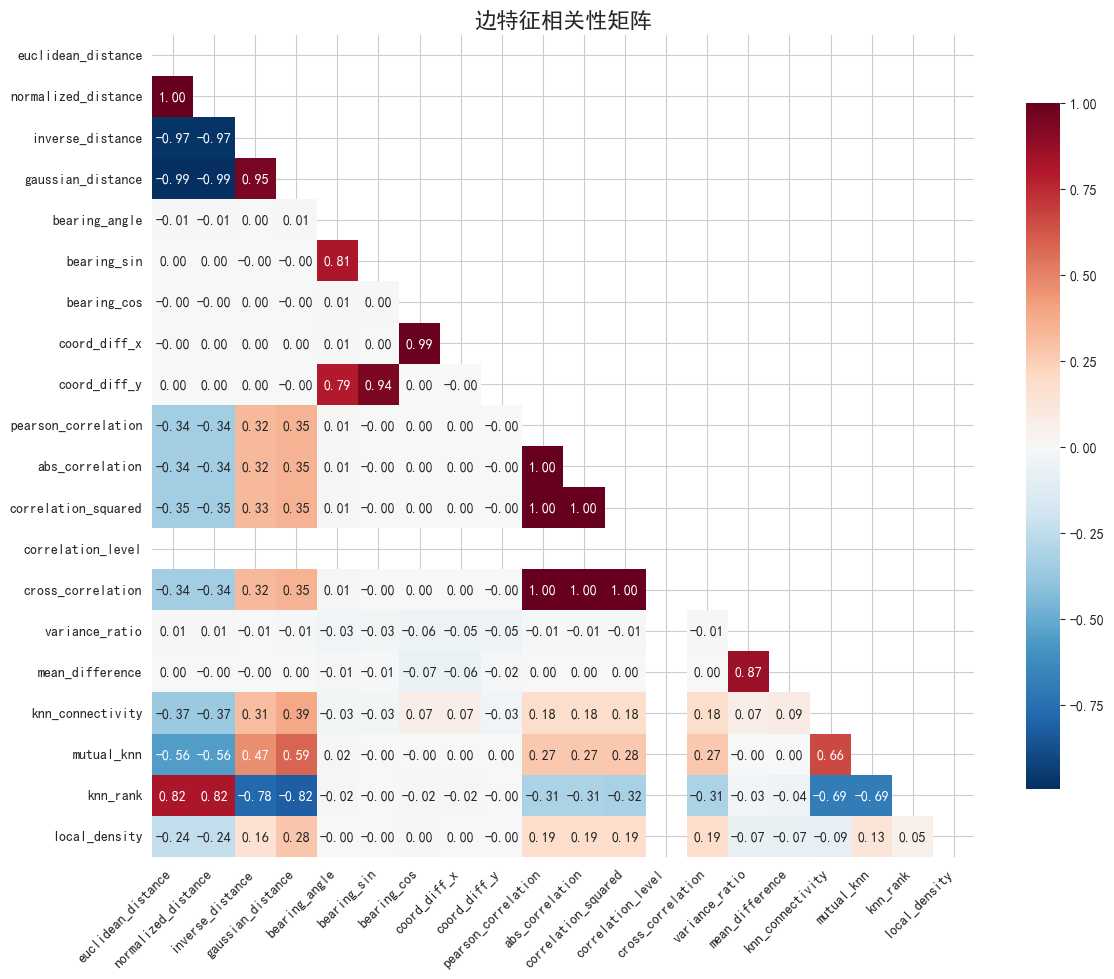

✅ 保存: 05_feature_correlation.png


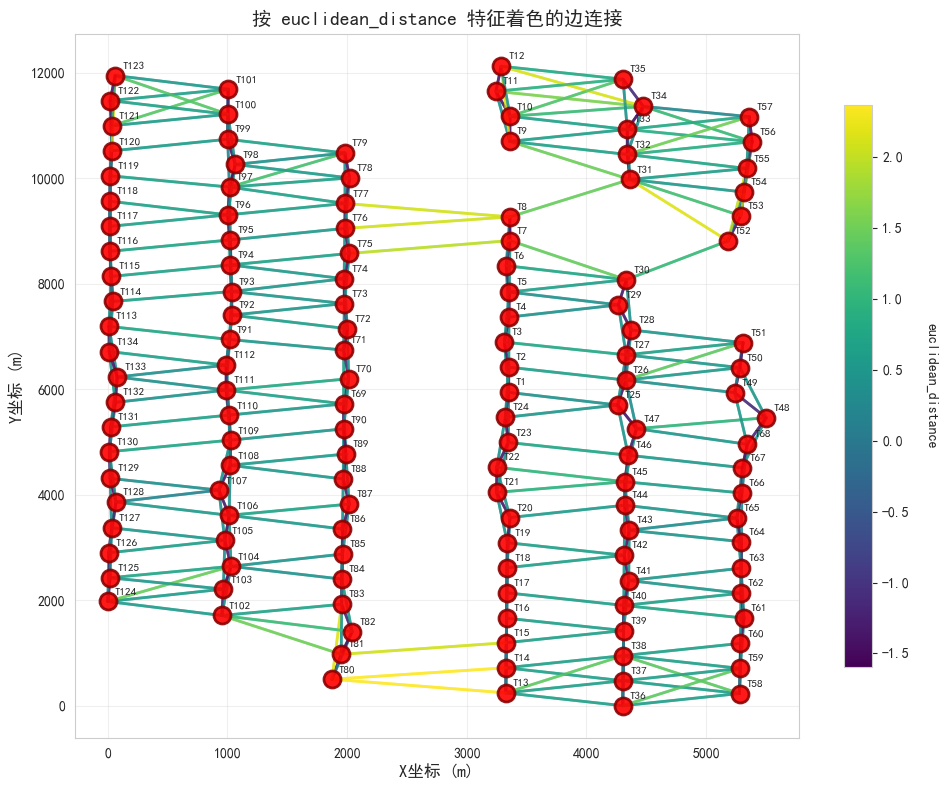

✅ 保存: 06_euclidean_distance_colored_edges.png


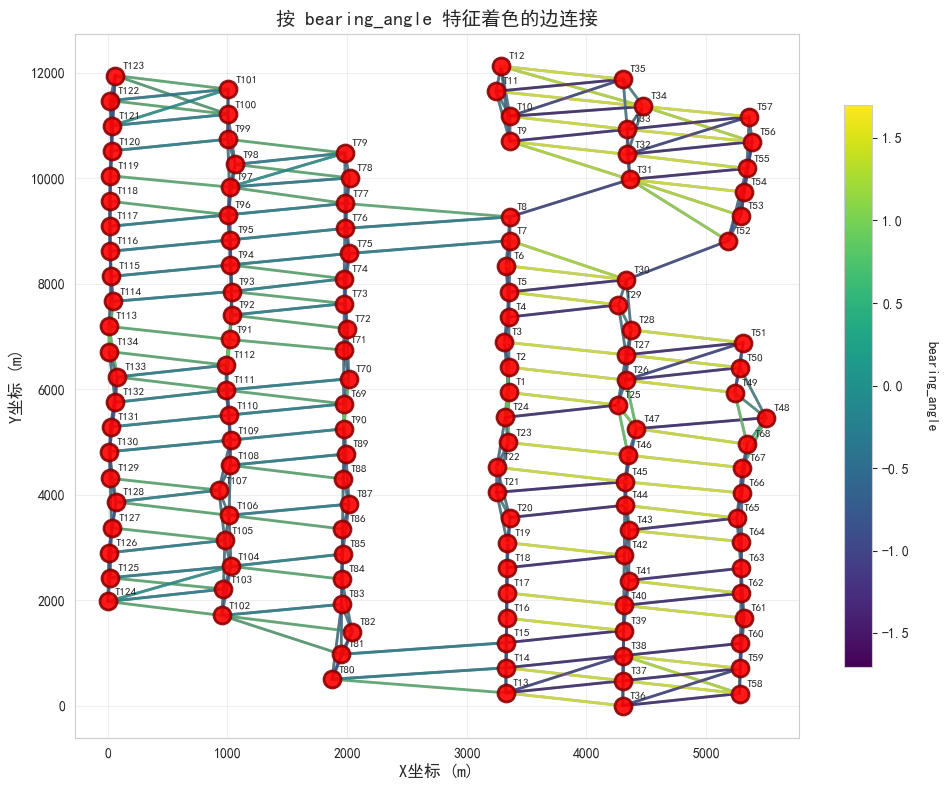

✅ 保存: 06_bearing_angle_colored_edges.png


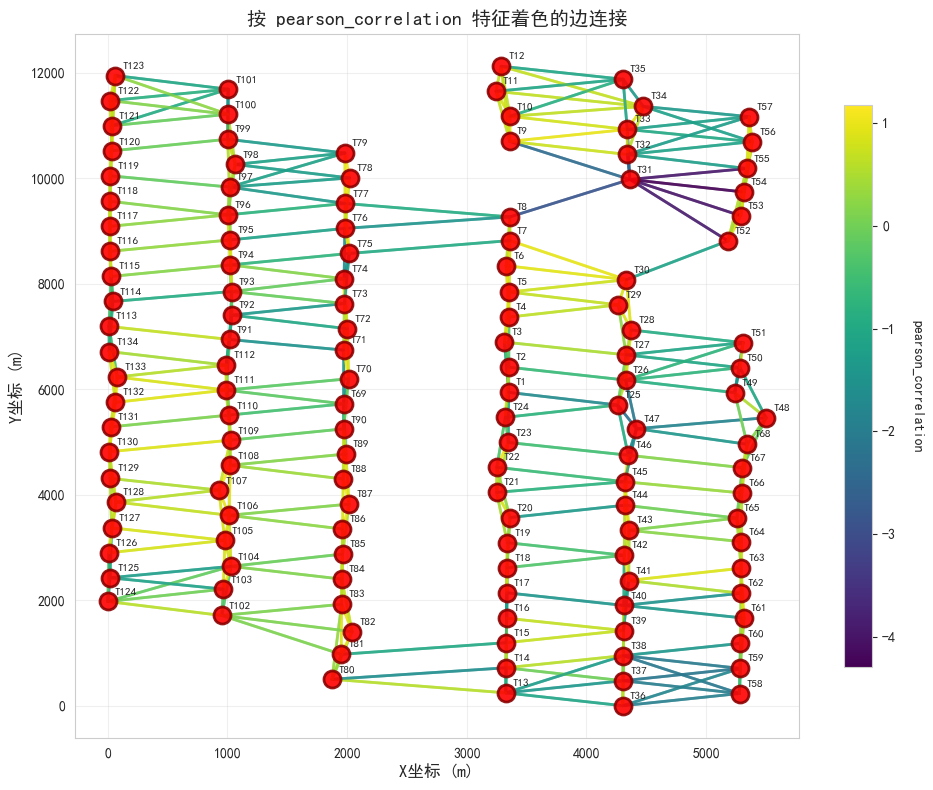

✅ 保存: 06_pearson_correlation_colored_edges.png


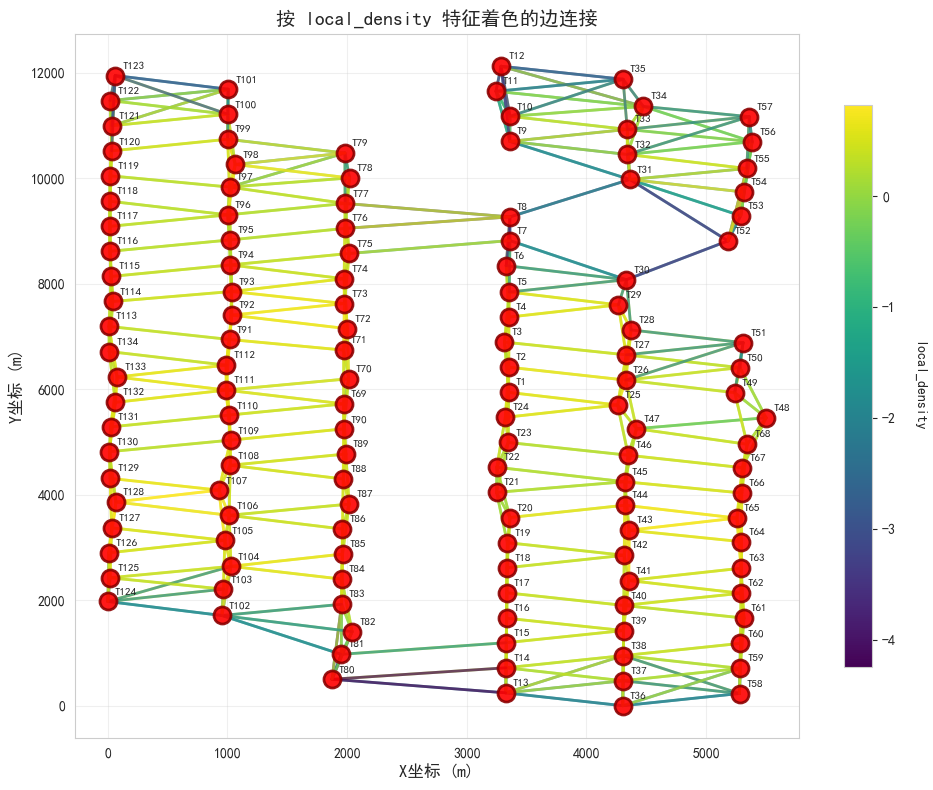

✅ 保存: 06_local_density_colored_edges.png


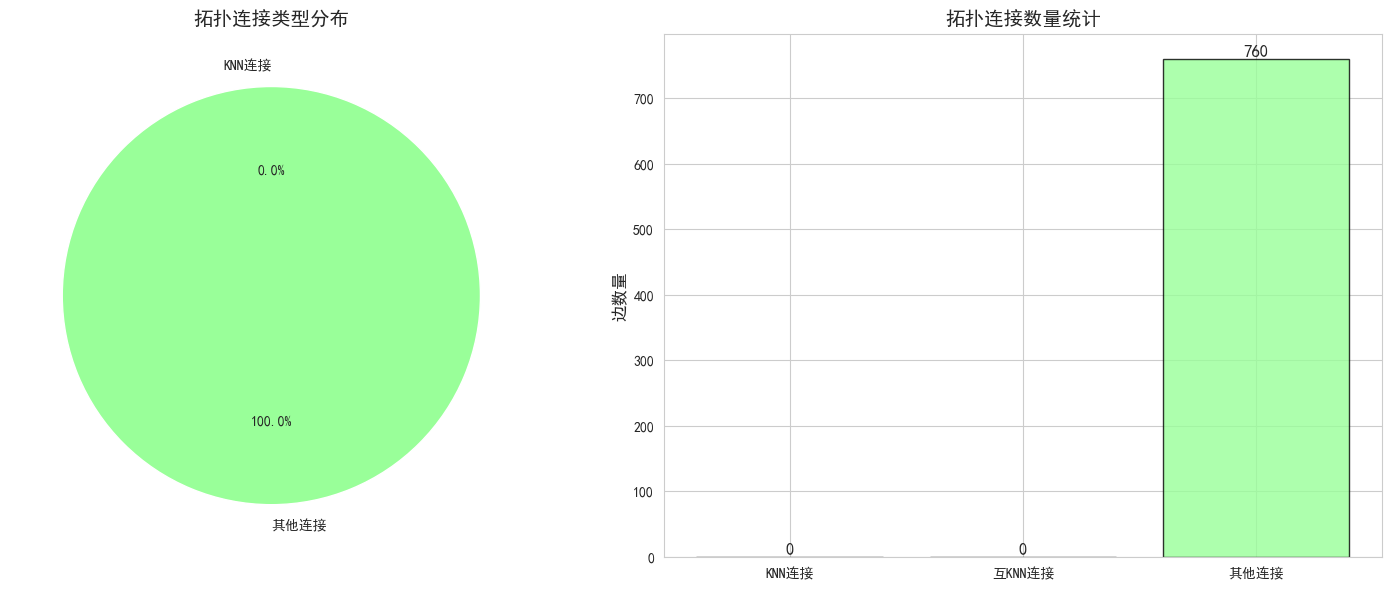

✅ 保存: 07_topology_features.png


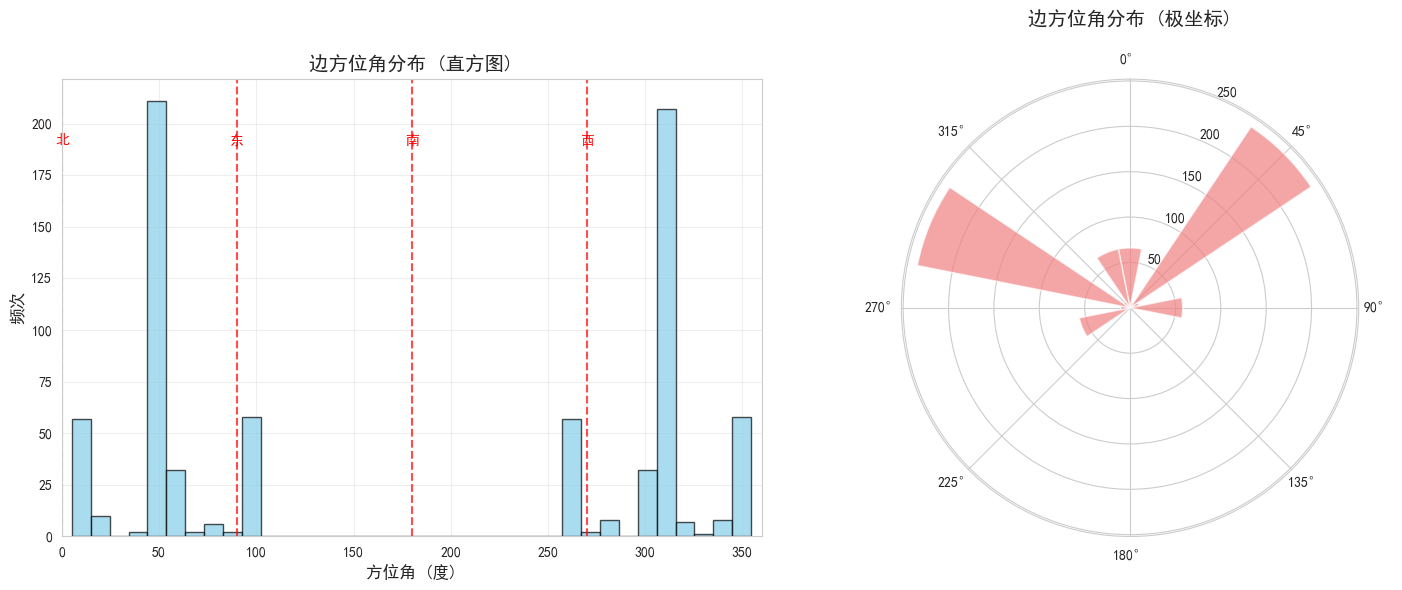

✅ 保存: 08_bearing_analysis.png


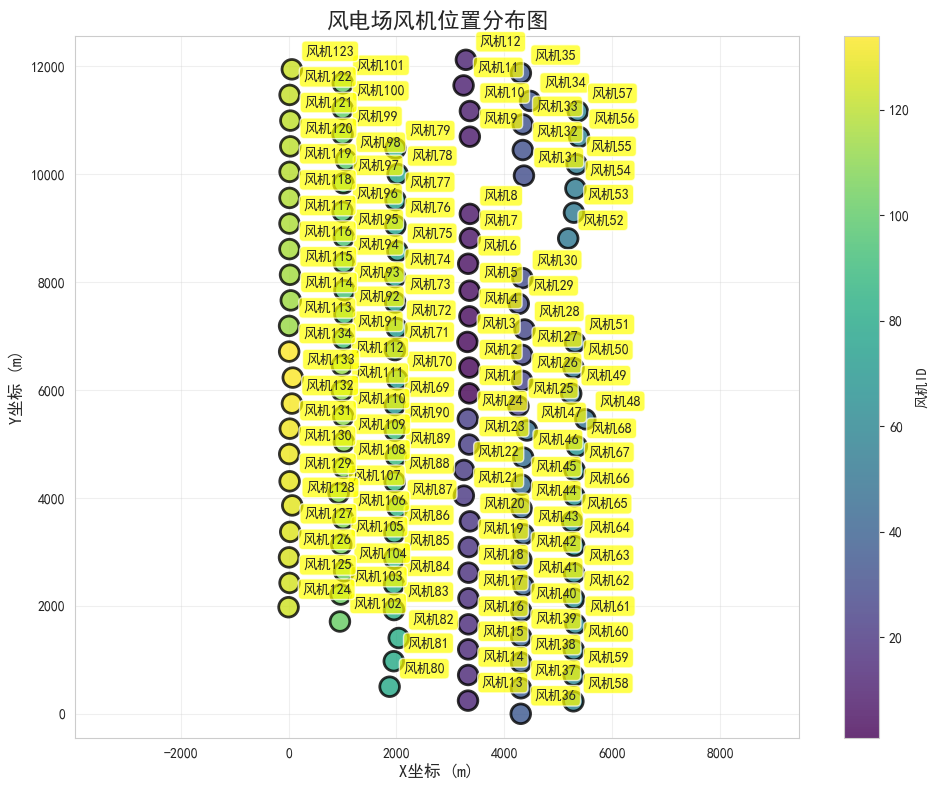

✅ 保存: 09_basic_positions.png


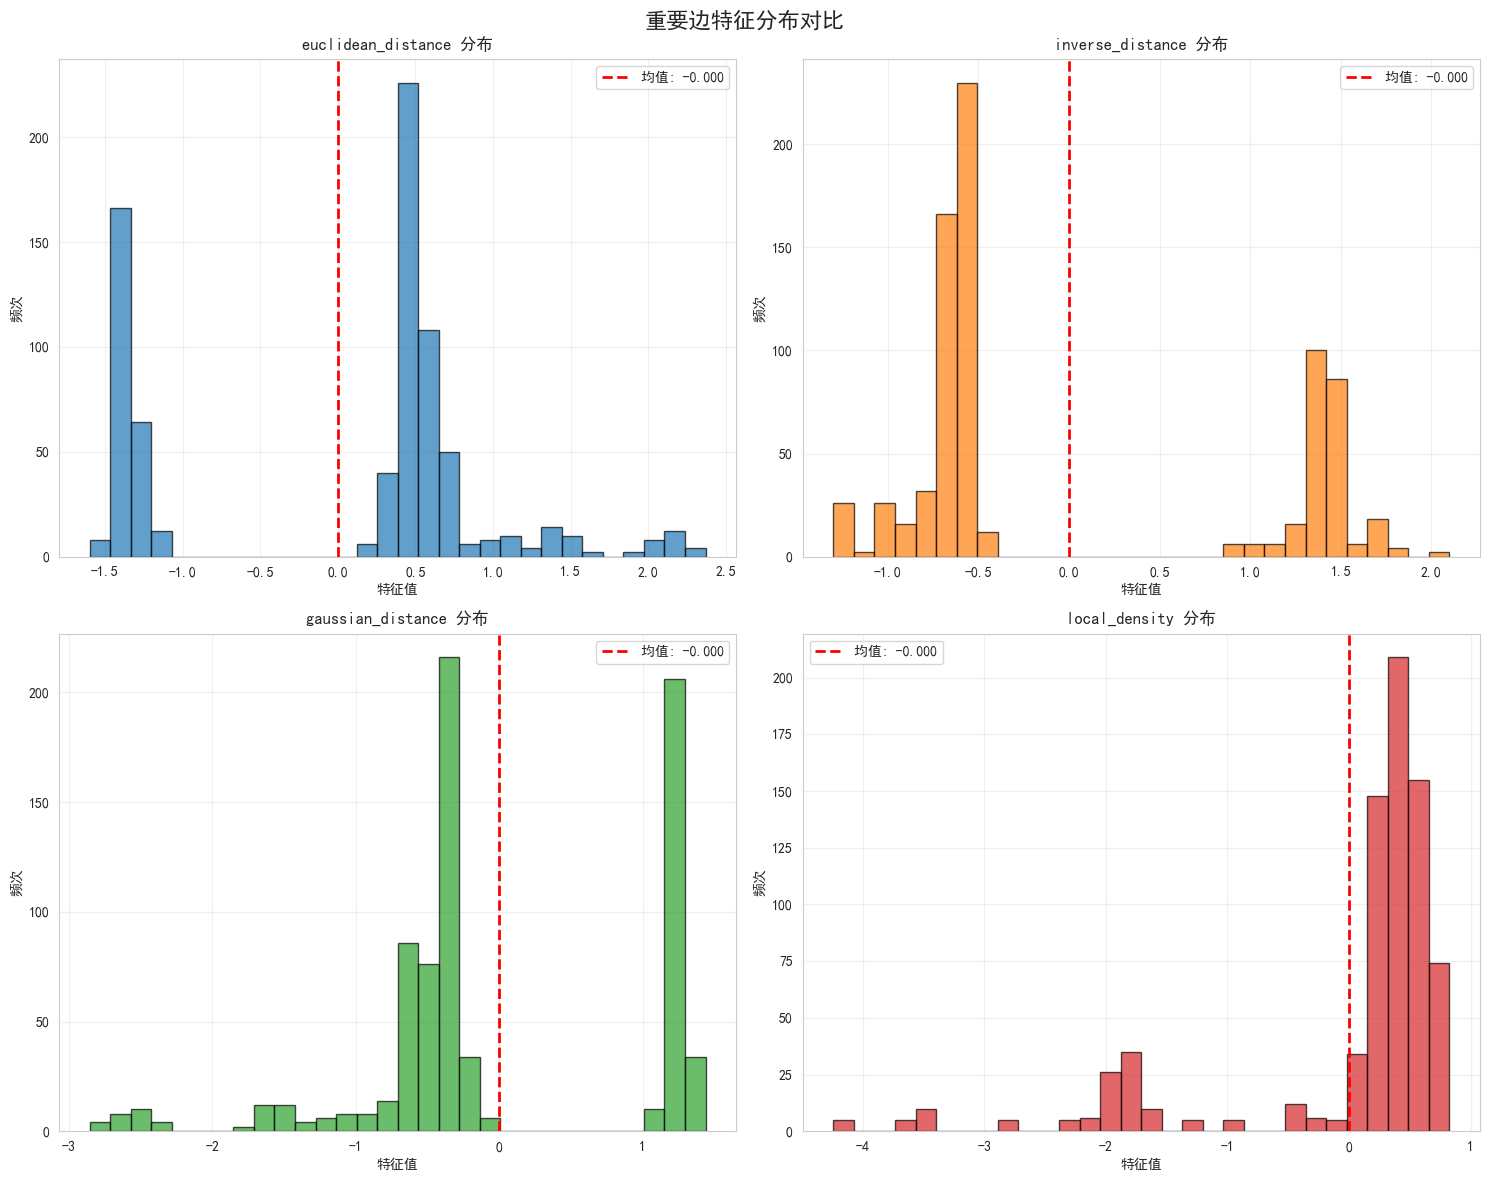

✅ 保存: 10_multiple_features.png
✅ 所有图表已保存到 wind_farm_plots/ 目录

🏭 风电场图网络统计汇总
📍 风机总数: 134
🔗 边连接数: 380 (唯一边)
📊 特征维度: 21

📏 距离统计:
  • 平均距离: -0.0m
  • 中位数距离: 0.4m
  • 最小距离: -1.6m
  • 最大距离: 2.4m
  • 标准差: 1.0m

🕸️ 连接度统计:
  • 平均连接度: 5.7
  • 最大连接度: 9
  • 最小连接度: 5
  • 图密度: 0.0426

🎯 拓扑特征统计:
  • KNN连接边数: 0
  • 互KNN连接边数: 0
  • KNN连接比例: 0.0%

💾 所有图表已保存到: wind_farm_plots/
✅ 所有可视化完成！


In [ ]:
class WindFarmVisualizer:
    def __init__(self, base_path="./", output_dir="visualized_output/"):
        self.base_path = base_path
        self.output_dir = output_dir
        self.turbine_data = None
        self.edge_index = None
        self.edge_features = None
        self.feature_names = None
        
        # 创建输出目录
        os.makedirs(output_dir, exist_ok=True)
        
    def load_all_data(self):
        """加载所有数据文件"""
        try:
            
            
            
            
            # 3. 加载边特征信息
            edge_attr_file = f"{self.base_path}edge_feature_knn_edge_attr.npy"
            self.edge_features = np.load(edge_attr_file)
            print(f"✅ 成功加载边特征信息: {self.edge_features.shape}")
            
            # 4. 加载特征名称
            feature_names_file = f"{self.base_path}edge_feature_knn_feature_names.txt"
            with open(feature_names_file, 'r') as f:
                self.feature_names = [line.strip() for line in f.readlines()]
            print(f"✅ 成功加载特征名称: {len(self.feature_names)} 个特征")
            
            return True
            
        except Exception as e:
            print(f"❌ 数据加载失败: {e}")
            return False
    
    def create_all_individual_plots(self):
        """创建所有单独的图表并保存"""
        if not self.load_all_data():
            return
        
        print("🎨 开始创建各个独立图表...")
        
        # 1. 主要图网络可视化
        self.plot_and_save_main_graph()
        
        # 2. 边特征热力图
        self.plot_and_save_edge_feature_heatmap()
        
        # 3. 距离分布直方图
        self.plot_and_save_distance_distribution()
        
        # 4. 连接度分布
        self.plot_and_save_degree_distribution()
        
        # 5. 特征相关性矩阵
        self.plot_and_save_feature_correlation()
        
        # 6. 按特征着色的边可视化
        self.plot_and_save_edges_by_feature()
        
        # 7. 拓扑特征可视化
        self.plot_and_save_topology_features()
        
        # 8. 方位角分析
        self.plot_and_save_bearing_analysis()
        
        # 9. 基础位置图
        self.plot_and_save_basic_positions()
        
        # 10. 多个重要特征的边可视化
        self.plot_and_save_multiple_edge_features()
        
        print(f"✅ 所有图表已保存到 {self.output_dir} 目录")
    
    def plot_and_save_main_graph(self):
        """绘制并保存主要图网络"""
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        
        # 创建NetworkX图
        G = nx.Graph()
        
        # 添加节点
        for _, row in self.turbine_data.iterrows():
            G.add_node(row['TurbID']-1, pos=(row['x'], row['y']))
        
        # 添加边并去重
        edge_set = set()
        for i in range(self.edge_index.shape[1]):
            src, dst = self.edge_index[0, i], self.edge_index[1, i]
            edge = tuple(sorted([src, dst]))
            if edge not in edge_set:
                distance = self.edge_features[i, 0]  # euclidean_distance
                G.add_edge(src, dst, weight=distance)
                edge_set.add(edge)
        
        # 获取位置
        pos = nx.get_node_attributes(G, 'pos')
        
        # 绘制边，根据距离着色
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        
        # 绘制边
        nx.draw_networkx_edges(G, pos, ax=ax, 
                             edge_color=weights, 
                             edge_cmap=plt.cm.viridis,
                             width=2, alpha=0.7)
        
        # 绘制节点
        nx.draw_networkx_nodes(G, pos, ax=ax,
                             node_color='red', 
                             node_size=300,
                             alpha=0.9,
                             edgecolors='darkred',
                             linewidths=2)
        
        # 添加节点标签
        labels = {i: f'T{i+1}' for i in range(len(self.turbine_data))}
        nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=10, font_weight='bold')
        
        ax.set_title(f'风电场KNN图网络 ({len(G.edges())}条边, {len(G.nodes())}个节点)', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('X坐标 (m)', fontsize=12)
        ax.set_ylabel('Y坐标 (m)', fontsize=12)
        
        # 添加颜色条
        sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                                   norm=Normalize(vmin=min(weights), vmax=max(weights)))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
        cbar.set_label('欧几里得距离 (m)', rotation=270, labelpad=20, fontsize=12)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}01_main_graph_network.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 01_main_graph_network.png")
    
    def plot_and_save_edge_feature_heatmap(self):
        """绘制并保存边特征热力图"""
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        
        # 选择前12个特征进行可视化
        n_features = min(12, len(self.feature_names))
        feature_data = self.edge_features[:, :n_features].T
        feature_labels = self.feature_names[:n_features]
        
        # 标准化数据
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        feature_data_scaled = scaler.fit_transform(feature_data.T).T
        
        # 显示前100条边的特征
        n_edges_show = min(100, feature_data_scaled.shape[1])
        
        im = ax.imshow(feature_data_scaled[:, :n_edges_show], 
                       cmap='RdBu_r', aspect='auto', interpolation='nearest')
        
        ax.set_title(f'边特征热力图 (标准化后) - 前{n_edges_show}条边', fontsize=16, fontweight='bold')
        ax.set_ylabel('特征名称', fontsize=12)
        ax.set_xlabel(f'边ID', fontsize=12)
        
        # 设置y轴标签
        ax.set_yticks(range(n_features))
        ax.set_yticklabels(feature_labels, fontsize=10)
        
        # 设置x轴
        ax.set_xticks(range(0, n_edges_show, max(1, n_edges_show//10)))
        
        plt.colorbar(im, ax=ax, shrink=0.8, label='标准化特征值')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}02_edge_feature_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 02_edge_feature_heatmap.png")
    
    def plot_and_save_distance_distribution(self):
        """绘制并保存距离分布"""
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        distances = self.edge_features[:, 0]  # euclidean_distance
        
        ax.hist(distances, bins=40, alpha=0.7, color='skyblue', edgecolor='black', linewidth=1)
        ax.set_title('风机间欧几里得距离分布', fontsize=16, fontweight='bold')
        ax.set_xlabel('距离 (m)', fontsize=12)
        ax.set_ylabel('频次', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # 添加统计信息
        mean_dist = np.mean(distances)
        median_dist = np.median(distances)
        std_dist = np.std(distances)
        
        ax.axvline(mean_dist, color='red', linestyle='--', linewidth=2,
                   label=f'均值: {mean_dist:.1f}m')
        ax.axvline(median_dist, color='orange', linestyle='--', linewidth=2,
                   label=f'中位数: {median_dist:.1f}m')
        
        # 添加统计文本框
        stats_text = f'统计信息:\n均值: {mean_dist:.1f}m\n中位数: {median_dist:.1f}m\n标准差: {std_dist:.1f}m\n最小值: {np.min(distances):.1f}m\n最大值: {np.max(distances):.1f}m'
        ax.text(0.7, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        
        ax.legend()
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}03_distance_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 03_distance_distribution.png")
    
    def plot_and_save_degree_distribution(self):
        """绘制并保存连接度分布"""
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        
        # 计算每个节点的度
        unique_edges = set()
        for i in range(self.edge_index.shape[1]):
            src, dst = self.edge_index[0, i], self.edge_index[1, i]
            edge = tuple(sorted([src, dst]))
            unique_edges.add(edge)
        
        degrees = np.zeros(len(self.turbine_data))
        for src, dst in unique_edges:
            degrees[src] += 1
            degrees[dst] += 1
        
        bars = ax.bar(range(len(degrees)), degrees, alpha=0.8, color='lightgreen', 
                     edgecolor='darkgreen', linewidth=1)
        ax.set_title('风机节点连接度分布', fontsize=16, fontweight='bold')
        ax.set_xlabel('风机ID', fontsize=12)
        ax.set_ylabel('连接度 (邻居数量)', fontsize=12)
        ax.grid(True, alpha=0.3, axis='y')
        
        # 设置x轴标签
        step = max(1, len(degrees)//20)
        ax.set_xticks(range(0, len(degrees), step))
        ax.set_xticklabels([f'T{i+1}' for i in range(0, len(degrees), step)], rotation=45)
        
        # 添加数值标签
        for i, bar in enumerate(bars):
            if i % (len(bars)//10 + 1) == 0:  # 只在部分柱子上显示数值
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                       f'{int(height)}', ha='center', va='bottom', fontsize=8)
        
        # 添加统计信息
        avg_degree = np.mean(degrees)
        ax.axhline(avg_degree, color='red', linestyle='--', linewidth=2,
                   label=f'平均连接度: {avg_degree:.1f}')
        ax.legend()
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}04_degree_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 04_degree_distribution.png")
    
    def plot_and_save_feature_correlation(self):
        """绘制并保存特征相关性矩阵"""
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        
        # 选择数值型特征进行相关性分析
        numeric_features = []
        numeric_indices = []
        
        for i, name in enumerate(self.feature_names):
            if name not in ['correlation_sign']:  # 排除分类特征
                numeric_features.append(name)
                numeric_indices.append(i)
        
        # 计算相关性矩阵
        feature_data = self.edge_features[:, numeric_indices]
        corr_matrix = np.corrcoef(feature_data.T)
        
        # 创建掩码来隐藏上三角
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
        # 使用seaborn绘制热力图
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                   square=True, cbar_kws={"shrink": 0.8}, fmt='.2f',
                   xticklabels=numeric_features, yticklabels=numeric_features, ax=ax)
        
        ax.set_title('边特征相关性矩阵', fontsize=16, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}05_feature_correlation.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 05_feature_correlation.png")
    
    def plot_and_save_edges_by_feature(self):
        """根据不同特征为边着色并保存"""
        important_features = ['euclidean_distance', 'bearing_angle', 'pearson_correlation', 'local_density']
        
        for feature_name in important_features:
            if feature_name in self.feature_names:
                fig, ax = plt.subplots(1, 1, figsize=(10, 8))
                
                feature_idx = self.feature_names.index(feature_name)
                feature_values = self.edge_features[:, feature_idx]
                
                # 绘制风机位置
                ax.scatter(self.turbine_data['x'], self.turbine_data['y'], 
                          c='red', s=150, alpha=0.9, zorder=5, 
                          edgecolors='darkred', linewidths=2)
                
                # 添加风机标签
                for _, row in self.turbine_data.iterrows():
                    ax.annotate(f'T{int(row["TurbID"])}', 
                               (row['x'], row['y']), 
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=8, ha='left', fontweight='bold')
                
                # 绘制边，根据特征值着色
                for i in range(self.edge_index.shape[1]):
                    src, dst = self.edge_index[0, i], self.edge_index[1, i]
                    x1, y1 = self.turbine_data.iloc[src]['x'], self.turbine_data.iloc[src]['y']
                    x2, y2 = self.turbine_data.iloc[dst]['x'], self.turbine_data.iloc[dst]['y']
                    
                    # 根据特征值确定颜色
                    if np.max(feature_values) != np.min(feature_values):
                        color_intensity = (feature_values[i] - np.min(feature_values)) / (np.max(feature_values) - np.min(feature_values))
                    else:
                        color_intensity = 0.5
                    
                    ax.plot([x1, x2], [y1, y2], 
                           color=plt.cm.viridis(color_intensity), 
                           alpha=0.7, linewidth=2)
                
                ax.set_title(f'按 {feature_name} 特征着色的边连接', fontsize=14, fontweight='bold')
                ax.set_xlabel('X坐标 (m)', fontsize=12)
                ax.set_ylabel('Y坐标 (m)', fontsize=12)
                ax.grid(True, alpha=0.3)
                
                # 添加颜色条
                sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                                           norm=Normalize(vmin=np.min(feature_values), 
                                                        vmax=np.max(feature_values)))
                sm.set_array([])
                cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
                cbar.set_label(f'{feature_name}', rotation=270, labelpad=20)
                
                plt.tight_layout()
                plt.savefig(f'{self.output_dir}06_{feature_name}_colored_edges.png', dpi=300, bbox_inches='tight')
                plt.show()
                print(f"✅ 保存: 06_{feature_name}_colored_edges.png")
    
    def plot_and_save_topology_features(self):
        """可视化并保存拓扑特征"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # 获取拓扑特征
        knn_connectivity = self.edge_features[:, self.feature_names.index('knn_connectivity')]
        mutual_knn = self.edge_features[:, self.feature_names.index('mutual_knn')]
        
        # 统计各类边的数量
        total_edges = len(knn_connectivity)
        knn_edges = np.sum(knn_connectivity)
        mutual_edges = np.sum(mutual_knn)
        other_edges = total_edges - knn_edges - mutual_edges
        
        # 确保没有负值
        other_edges = max(0, other_edges)
        
        # 左图：饼图
        if knn_edges > 0 or mutual_edges > 0 or other_edges > 0:
            labels = ['KNN连接', '互KNN连接', '其他连接']
            sizes = [knn_edges, mutual_edges, other_edges]
            colors = ['#ff9999', '#66b3ff', '#99ff99']
            
            # 过滤掉值为0的项
            filtered_data = [(label, size, color) for label, size, color in zip(labels, sizes, colors) if size > 0]
            if filtered_data:
                labels_f, sizes_f, colors_f = zip(*filtered_data)
                wedges, texts, autotexts = ax1.pie(sizes_f, labels=labels_f, colors=colors_f, 
                                                 autopct='%1.1f%%', startangle=90)
                ax1.set_title('拓扑连接类型分布', fontsize=14, fontweight='bold')
        
        # 右图：柱状图
        categories = ['KNN连接', '互KNN连接', '其他连接']
        values = [knn_edges, mutual_edges, other_edges]
        colors = ['#ff9999', '#66b3ff', '#99ff99']
        
        bars = ax2.bar(categories, values, color=colors, alpha=0.8, edgecolor='black')
        ax2.set_title('拓扑连接数量统计', fontsize=14, fontweight='bold')
        ax2.set_ylabel('边数量', fontsize=12)
        
        # 添加数值标签
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{int(value)}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}07_topology_features.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 07_topology_features.png")
    
    def plot_and_save_bearing_analysis(self):
        """分析并保存方位角分布"""
        # 创建子图：一个普通直方图，一个极坐标图
        fig = plt.figure(figsize=(15, 6))
        
        bearing_angles = self.edge_features[:, self.feature_names.index('bearing_angle')]
        bearing_degrees = np.degrees(bearing_angles) % 360  # 确保在0-360范围内
        
        # 左图：普通直方图
        ax1 = plt.subplot(121)
        n, bins, patches = ax1.hist(bearing_degrees, bins=36, alpha=0.7, color='skyblue', 
                                   edgecolor='black', linewidth=1)
        ax1.set_title('边方位角分布 (直方图)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('方位角 (度)', fontsize=12)
        ax1.set_ylabel('频次', fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(0, 360)
        
        # 添加主要方向标记
        directions = [0, 90, 180, 270]
        direction_names = ['北', '东', '南', '西']
        for angle, name in zip(directions, direction_names):
            ax1.axvline(angle, color='red', linestyle='--', alpha=0.7)
            ax1.text(angle, max(n) * 0.9, name, ha='center', fontweight='bold', color='red')
        
        # 右图：极坐标直方图
        ax2 = plt.subplot(122, projection='polar')
        
        theta = np.radians(bearing_degrees)
        n_bins = 16
        theta_bins = np.linspace(0, 2*np.pi, n_bins+1)
        hist, _ = np.histogram(theta, bins=theta_bins)
        
        # 绘制极坐标直方图
        width = 2*np.pi / n_bins
        bars = ax2.bar(theta_bins[:-1], hist, width=width, alpha=0.7, color='lightcoral')
        
        ax2.set_title('边方位角分布 (极坐标)', fontsize=14, fontweight='bold', pad=20)
        ax2.set_theta_zero_location('N')  # 北方向为0度
        ax2.set_theta_direction(-1)  # 顺时针
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}08_bearing_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 08_bearing_analysis.png")
    
    def plot_and_save_basic_positions(self):
        """绘制并保存基础位置图"""
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        # 绘制风机位置
        scatter = ax.scatter(self.turbine_data['x'], self.turbine_data['y'], 
                           c=self.turbine_data['TurbID'], cmap='viridis', 
                           s=200, alpha=0.8, edgecolors='black', linewidth=2)
        
        # 添加风机标签
        for _, row in self.turbine_data.iterrows():
            ax.annotate(f'风机{int(row["TurbID"])}', 
                       (row['x'], row['y']), 
                       xytext=(10, 10), textcoords='offset points',
                       fontsize=10, ha='left', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
        
        ax.set_title('风电场风机位置分布图', fontsize=16, fontweight='bold')
        ax.set_xlabel('X坐标 (m)', fontsize=12)
        ax.set_ylabel('Y坐标 (m)', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        plt.colorbar(scatter, ax=ax, label='风机ID')
        plt.axis('equal')
        
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}09_basic_positions.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 09_basic_positions.png")
    
    def plot_and_save_multiple_edge_features(self):
        """绘制多个重要特征的对比"""
        features_to_plot = ['euclidean_distance', 'inverse_distance', 'gaussian_distance', 'local_density']
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.ravel()
        
        for i, feature_name in enumerate(features_to_plot):
            if feature_name in self.feature_names:
                ax = axes[i]
                feature_idx = self.feature_names.index(feature_name)
                feature_values = self.edge_features[:, feature_idx]
                
                # 绘制直方图
                ax.hist(feature_values, bins=30, alpha=0.7, color=f'C{i}', edgecolor='black')
                ax.set_title(f'{feature_name} 分布', fontsize=12, fontweight='bold')
                ax.set_xlabel('特征值')
                ax.set_ylabel('频次')
                ax.grid(True, alpha=0.3)
                
                # 添加统计信息
                mean_val = np.mean(feature_values)
                ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                          label=f'均值: {mean_val:.3f}')
                ax.legend()
        
        plt.suptitle('重要边特征分布对比', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{self.output_dir}10_multiple_features.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ 保存: 10_multiple_features.png")
    
    def print_summary_statistics(self):
        """打印汇总统计信息"""
        print("\n" + "="*50)
        print("🏭 风电场图网络统计汇总")
        print("="*50)
        
        n_turbines = len(self.turbine_data)
        n_edges = self.edge_index.shape[1]
        n_features = len(self.feature_names)
        
        # 计算唯一边数
        unique_edges = set()
        for i in range(n_edges):
            src, dst = self.edge_index[0, i], self.edge_index[1, i]
            edge = tuple(sorted([src, dst]))
            unique_edges.add(edge)
        
        n_unique_edges = len(unique_edges)
        
        print(f"📍 风机总数: {n_turbines}")
        print(f"🔗 边连接数: {n_unique_edges} (唯一边)")
        print(f"📊 特征维度: {n_features}")
        
        # 距离统计
        distances = self.edge_features[:, 0]
        print(f"\n📏 距离统计:")
        print(f"  • 平均距离: {np.mean(distances):.1f}m")
        print(f"  • 中位数距离: {np.median(distances):.1f}m")
        print(f"  • 最小距离: {np.min(distances):.1f}m")
        print(f"  • 最大距离: {np.max(distances):.1f}m")
        print(f"  • 标准差: {np.std(distances):.1f}m")
        
        # 连接度统计
        degrees = np.zeros(n_turbines)
        for src, dst in unique_edges:
            degrees[src] += 1
            degrees[dst] += 1
        
        print(f"\n🕸️ 连接度统计:")
        print(f"  • 平均连接度: {np.mean(degrees):.1f}")
        print(f"  • 最大连接度: {int(np.max(degrees))}")
        print(f"  • 最小连接度: {int(np.min(degrees))}")
        print(f"  • 图密度: {n_unique_edges*2/(n_turbines*(n_turbines-1)):.4f}")
        
        # 拓扑特征统计
        if 'knn_connectivity' in self.feature_names:
            knn_conn = self.edge_features[:, self.feature_names.index('knn_connectivity')]
            mutual_knn = self.edge_features[:, self.feature_names.index('mutual_knn')]
            
            print(f"\n🎯 拓扑特征统计:")
            print(f"  • KNN连接边数: {int(np.sum(knn_conn))}")
            print(f"  • 互KNN连接边数: {int(np.sum(mutual_knn))}")
            print(f"  • KNN连接比例: {np.sum(knn_conn)/len(knn_conn)*100:.1f}%")
        
        print(f"\n💾 所有图表已保存到: {self.output_dir}")
        print("="*50)

def main():
    """主函数"""
    print("🚀 启动风电场图网络可视化分析...")
    print("📁 将创建单独的图表文件并保存")
    
    # 创建可视化器
    visualizer = WindFarmVisualizer()
    
    # 创建所有独立图表
    visualizer.create_all_individual_plots()
    
    # 打印统计汇总
    visualizer.print_summary_statistics()
    
    print("✅ 所有可视化完成！")

if __name__ == "__main__":
    main()